In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# this will load our data set 
df = pd.read_csv('Weather_Records.csv')

Data_frame_copy = df.copy()

Data_frame_copy['StartTime(UTC)'] = pd.to_datetime(Data_frame_copy['StartTime(UTC)'])
Data_frame_copy['EndTime(UTC)'] = pd.to_datetime(Data_frame_copy['EndTime(UTC)'])

Data_frame_copy['StartTimeHour'] = Data_frame_copy['StartTime(UTC)'].dt.hour
Data_frame_copy['EndTimeHour'] = Data_frame_copy['EndTime(UTC)'].dt.hour


Data_frame_copy['Duration'] = (Data_frame_copy['EndTime(UTC)'] - Data_frame_copy['StartTime(UTC)']).dt.total_seconds() / 3600
print(Data_frame_copy[['StartTime(UTC)', 'EndTime(UTC)', 'Duration']].head())



       StartTime(UTC)        EndTime(UTC)  Duration
0 2016-01-06 23:14:00 2016-01-07 00:34:00  1.333333
1 2016-01-07 04:14:00 2016-01-07 04:54:00  0.666667
2 2016-01-07 05:54:00 2016-01-07 15:34:00  9.666667
3 2016-01-08 05:34:00 2016-01-08 05:54:00  0.333333
4 2016-01-08 13:54:00 2016-01-08 15:54:00  2.000000


In [12]:

Data_frame_copy['Month'] = Data_frame_copy['StartTime(UTC)'].dt.month

def Seasons(month):
    if month in [12 , 1 , 2]:
        return 'winter'
    elif month in [3 , 4 , 5]:
        return 'spring'
    elif month in [6 , 7 , 8]:
        return 'summer'
    elif month in [9 , 10 , 11]:
        return 'autumn'
    else:
        return 'unknown'


Data_frame_copy['Season'] = Data_frame_copy['Month'].apply(Seasons)   

print(Data_frame_copy['Season'].head())

0    winter
1    winter
2    winter
3    winter
4    winter
Name: Season, dtype: object


### Encoding Categorical Variables:
● Convert the Severity column into numerical values using label encoding or
one-hot encoding. Explain your choice of method

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

Data_frame_copy['Severity_Encoded'] = le.fit_transform(Data_frame_copy['Severity'])

print(Data_frame_copy[['Severity' , 'Severity_Encoded']].head(10))

  Severity  Severity_Encoded
0    Light                 1
1    Light                 1
2    Light                 1
3    Light                 1
4    Light                 1
5    Light                 1
6   Severe                 3
7    Light                 1
8   Severe                 3
9    Light                 1


### Task D: Advanced Analysis (20 Marks)
#### 1. Correlation Analysis:
● Calculate the correlation between Precipitation(in) and the Duration feature.

● Visualize the correlation using a heatmap.

● Write a short explanation of the insights derived from the correlation analysis.

#### 2. Outlier Detection:
● Identify outliers in the Precipitation(in) column using the IQR (Interquartile
Range) method.

● Visualize the outliers using a boxplot.

● Explain how you would handle these outliers.

#### 3. Geospatial Analysis:
● Plot the locations of all weather events on a map using the LocationLat and
LocationLng columns.

● Use a scatter plot for this task.

● Write a short analysis of the geographical distribution of weather events.

#### 1. Correlation Analysis:
##### Calculate the correlation between Precipitation(in) and the Duration feature.

In [14]:
correlation = Data_frame_copy['Precipitation(in)'].corr(Data_frame_copy['Duration'])
print(f"Correlation between Precipitation and Duration: {correlation:.3f}")

Correlation between Precipitation and Duration: 0.016


#### ● Visualize the correlation using a heatmap.

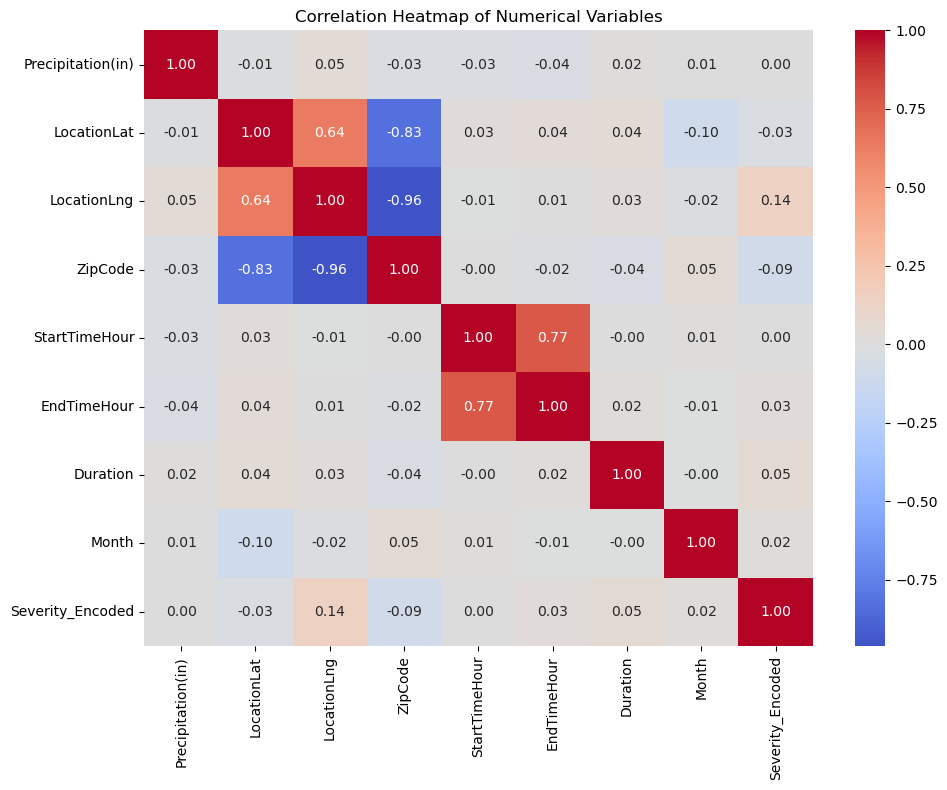

In [15]:
plt.figure(figsize=(10,8))

numerical_columns = Data_frame_copy.select_dtypes(include=[np.number]).columns

correlation_matrix = Data_frame_copy[numerical_columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()